# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np# importar librerías

In [113]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [114]:
print(plans.head(5))# mostrar las primeras 5 filas de plans

  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [115]:
print(users.head())# mostrar las primeras 5 filas de users

   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [116]:
print(usage.head())# mostrar las primeras 5 filas de usage

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [117]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [118]:
print(plans.info())# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
None


In [119]:
print(users.info())# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
None


In [120]:
print(usage.info())# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
None


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [121]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [122]:
print(usage.isna().sum())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- City con el 11% de valoes nulos aprox.
-  churn_date con el 88% aprox.
- Indica qué harías: ¿imputar, eliminar, ignorar?
- city -- investigar
-  churn_date -- eliminar la columna 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [123]:
print(users.describe())# explorar columnas numéricas de users

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`
- de user_id se ve bastante consistente, el numero mas bajo es 10000 y el mas alto 13999 lo quwe me da los 4000 usuarios y los promedios se ven bastante coherentes
- La columna `age`
- de age igual se ve bastante coherente a esepcion de el valor minimo que es de -999

In [124]:
print(usage.describe())# explorar columnas numéricas de usage

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` tienen 40,000 regristros pero solo deberia tener 4000, aun asi el valor mas bajo de 'user_id' es de 10,000 y el mas alto de 13,999 eso quierwe decir que quiza el resto de usuarios aparece como nulo 
- Las columnas  duration y length tienen valores faltantes para llegar a los 40,000 que marcan los usuarios pero tienen mas de los 4000 con los que creo que deberia poder hacer el analisis, eso quiere decir que tiene muchos valores faltantes o nulos 

In [125]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` presenta 3531 usuarios de los 4000, son 7 ciudades de las cuales Bogotá es la mas frecuente con 808 apariciones   
- La columna `plan` son los 4000 regristos de los dos planes y el basico es el mas popular con 2595 usuarios 

In [126]:
# explorar columna categórica de usage
print(usage['type'].describe()) # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` aqui de nuevo me aparecen 40,000 regristros, y de esos 22,092 son de la categoria de 'text'


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- principalmente en 'age',hay otras columnas don problemas pero creo que ninguno como 'age'
- ¿Qué acción tomarías?  
 seria necesario sustituir esos valores primero por NAN y luiego revisar que se puede o debe hacver con ellos 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [127]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors = 'coerce')# completa el código

In [128]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors = 'coerce')# completa el código

In [129]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`hay registros del 2026 solo son 40, la mayoria de los registros si cae dentro de los demas años 

In [130]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date` pues parece normal, toamndo en cuenta los 40000 usuarios a este solo le faltan 50 para que se complete el regisrtro de fechas de cada uno 
Basaremos el análisis en estas fechas.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- creo que solo los 40 del año 2026
- ¿Qué harías con ellas?
pues creo que eliminarlos no causaria un impacto sigmificativo en el analisis 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [131]:

# Reemplazar -999 por la mediana de age
age_mediana =  users[users['age'] != -999]['age'].median()
users['age'] =  users['age'].replace(-999, age_mediana)
# Verificar cambios
print(users['age'].describe())


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [132]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
print(users['city'].describe())

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object


In [133]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
print(users['reg_date'].describe())

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [134]:
# Verificación MAR en usage (Missing At Random) para duration
print(pd.crosstab(usage['type'], usage['duration'].isna()))

duration  False  True 
type                  
call      17908      0
text         16  22076


In [135]:
# Verificación MAR en usage (Missing At Random) para length
print(pd.crosstab(usage['type'], usage['length'].isna()))

length  False  True 
type                
call       12  17896
text    22092      0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Ambos son MAR porque dependen de otra columna
y respecto a los datos se ven bastante consistentes, a esepcion de los 16 de texto que marca con duracion (no puede porque es un mensaje y es texto, a menos que sea un mensaje de voz) y las 12 llamadas que marca como largas 


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [136]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)



,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [137]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes"})

usage_agg = usage_agg.rename(columns={"is_call": "cant_llamadas"})

usage_agg = usage_agg.rename(columns={"duration": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [138]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [139]:
# Resumen estadístico de las columnas numéricas
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())
print()

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000



In [140]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).round(3) * 100

Basico     64.9
Premium    35.1
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

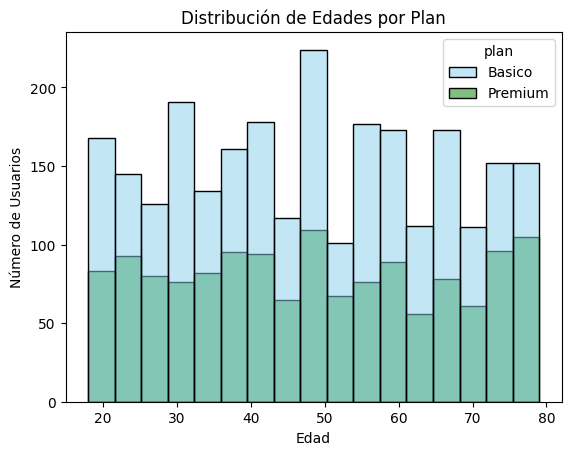

In [141]:

# Histograma para visualizar la edad (age)

sns.histplot(
    data = user_profile,
    x = 'age',
    hue = 'plan',
    palette = ['skyblue','green']
)
plt.title('Distribución de Edades por Plan')
plt.xlabel('Edad')
plt.ylabel('Número de Usuarios')
plt.show()



💡Insights: 
- Distribución uniforme con relacion a las edades desde los 18 hasta los 80, y hay una diferencia sigmificativa en el numero de usuarios que prefieren el plan basico con respecto al premium

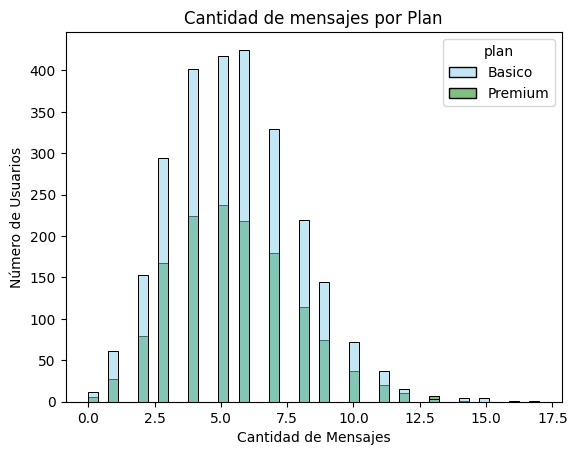

In [142]:

# Histograma para visualizar la cant_mensajes
sns.histplot(
    data = user_profile,
    x = 'cant_mensajes',
    hue = 'plan',
    palette = ['skyblue','green']
)
plt.title('Cantidad de mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Número de Usuarios')

plt.show()


💡Insights: 
- La grafica muestra mayor cantidad de usuarios que mandan entre 3 a 8 mensajes duerante el tiempo de su plan, haciendo que la grafica tenga un sesgo hacia la derecha 

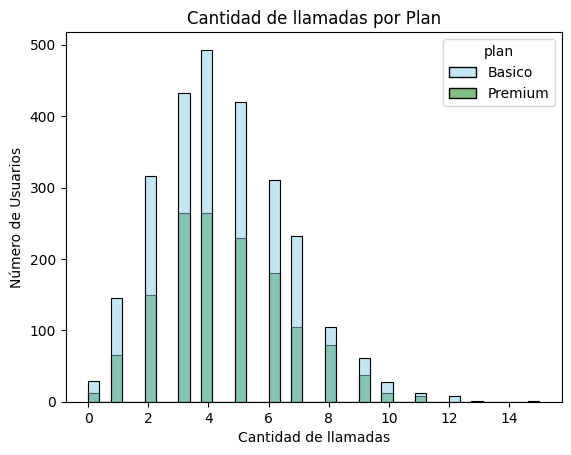

In [143]:
# Histograma para visualizar la cant_llamadas

sns.histplot(
    data = user_profile,
    x = 'cant_llamadas',
    hue = 'plan',
    palette = ['skyblue','green']
)
plt.title('Cantidad de llamadas por Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Número de Usuarios')

plt.show()


💡Insights: 
- la mayoria de los datos de las llamadas realizadas por los usuarios se concentran entre 2 y 7 llamadas en la duracion del plan, existe una disminucion de usuarios mientras aumenta el numero de llamadas realizadas, la grafica tiene un sesgo hacia la dertecha 

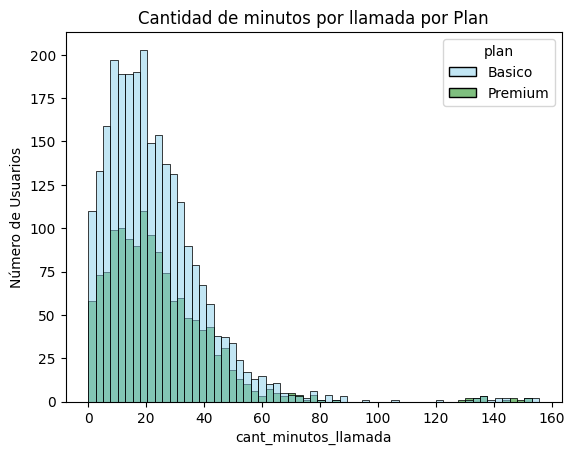

In [144]:

# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data = user_profile,
    x = 'cant_minutos_llamada',
    hue = 'plan',
    palette = ['skyblue','green']
)
plt.title('Cantidad de minutos por llamada por Plan')
plt.xlabel('cant_minutos_llamada')
plt.ylabel('Número de Usuarios')

plt.show()


💡Insights: 
-La cantidad de minutos que duran las llamadas esta entre 1 y 30 minutos, despues de este rango la grafica nos muestra que disminuye el numero de usuarios que realiza llamadas con duraciones mas largas siendo el maximo aproximado 155 min. La grafica muestra un sesgo hjacia la derecha 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

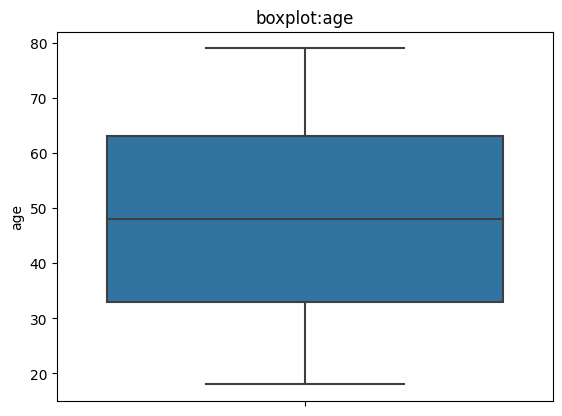

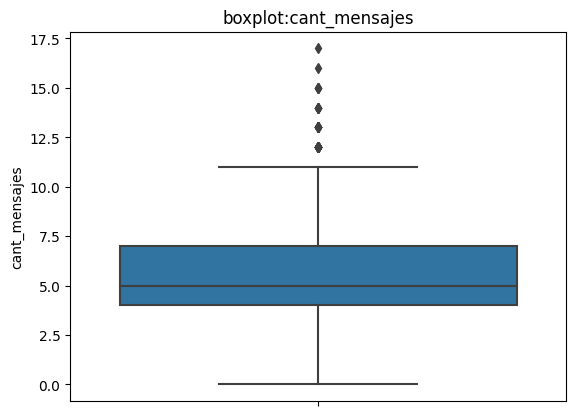

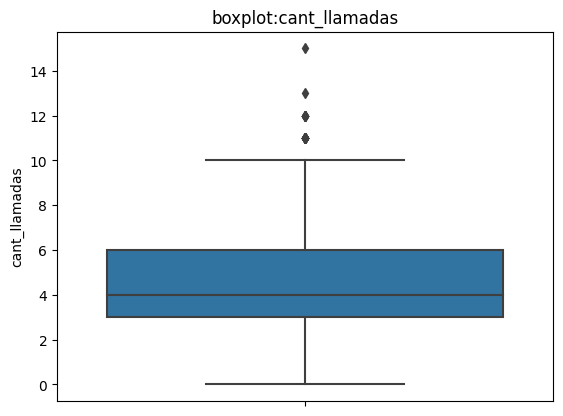

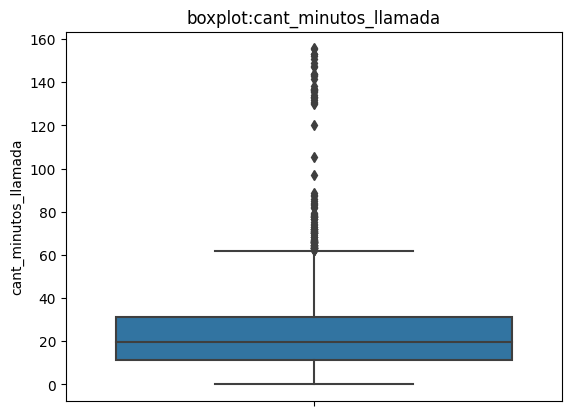

In [145]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columna in columnas_numericas:
    sns.boxplot(
        data=user_profile,
        y=columna
    )
    plt.title(f'boxplot:{columna}')
    plt.show()


💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Presenta outliers
- cant_llamadas: Presenta outliers
- cant_minutos_llamada: Presenta outliers

In [146]:

# Calcular límites con el método IQR
columnas_limites = [  'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for columna in columnas_limites:

    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR





In [147]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- Creo que si es recomendable mantenerlos porque la cantidad maxima son 17 mensajes enviados, y aunque la medfia es de 5, es un valor que es razonable en los usuarios ademas se puede considerar que no es un valor aislado si no que es progresivo y eso se puede apreciar en el boxplot.
- cant_llamadas: mantener o no outliers, porqué?
- Igualmente creo que es recomendable mantenerlos porque aunque parecen alejados de la mediana, tampoco es una cantidad exagerada y al igual que los mensajes no son datos aislados si no que se puede apreciar como hay un "camino" previo de datos que se salen de lo que se considera el estandar.
- cant_minutos_llamada: mantener o no outliers, porqué?
- Creo que al igual que los dos casos anteriores se pueden dejar, quiza dependa de los datos que se quieran recopilar, ya que si se busca informacion de los usuarios promedio, pues quiza no sean necesarios, pero si se busca un analisis mas completo se pueden quedar, dado que en la grafica se puede apreciar que las llamadas mas largas no son solo echas por un unico usuario, si no que casi al final de la ghrafica se muestra un "remonte" por parte de unos pocos usuarios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [154]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),

    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10)
]


opciones = [
    'Bajo uso',
    'Uso medio'
]

user_profile['grupo_uso'] = np.select(
    condiciones,
    opciones,
    default='Alto uso'
)


In [155]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [156]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age'] < 30),

    (user_profile['age'] < 60)
]

# Opciones
opciones = [
    'Joven',
    'Adulto'
]

# Crear columna
user_profile['grupo_edad'] = np.select(
    condiciones,
    opciones,
    default='Adulto Mayor'
)

In [160]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

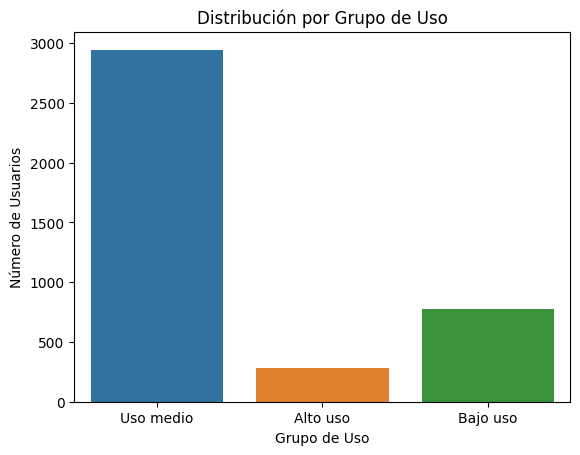

In [158]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Número de Usuarios')

plt.show()

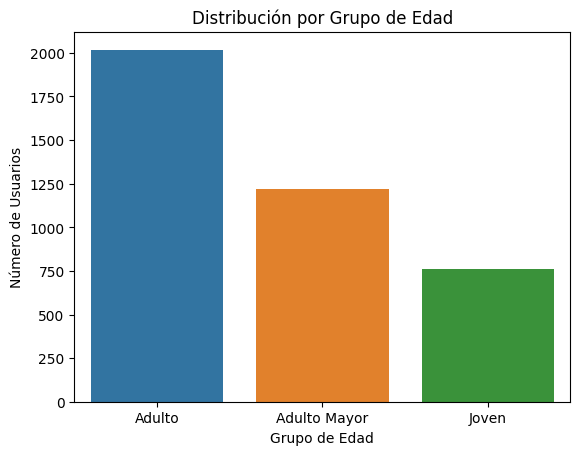

In [159]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Número de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- En la columna de 'age' se tenian valoe se -999 los cuales pues son imposibles, entonces se reemplazaron por la mediana para poder trabajar mejor esos datos.
- En la columna de 'reg_date' se encontraron datos del 2026 y eso no es posibnle porque solo se tomaron en cuenta hasta el 2024, pero cabe resaltar que eran pocos datos asi que se consideraron como nulos
- En la columna 'city' se encontraron ciudades que aparecian como "?" y esos datos se reemplazaron por NaN

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- los cliemtes se segmentaron por uso y por edad.
-  Edad: Las personas adultas (entre 30 y 59 años) son el mayor porcwentaje de usuarios, despues le siguen las personas mayores (60 a 80) y por ultimo las personas jovenes (18 a 29)
-  Uso: La mayoria de los usuarios hacen un uso medio de los servicios de mensajeria y telefonia (menos de 10 mensajes y llamadas), despuies le siguen los de uso bajo (menos de 5 llamadas y mensajes) y por ultimo le siguen las de uso alto
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- Pues creo que los usuarios de "Uso medio" y los "Adultos" son donde se concentra los valosres de u8suarios mas altos.
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- En cantidad de mensajes, en cantidad llamadas y en minutos de llamadas, no siento que sean grandes implicaciones para el negocio dado que la cantidad de usuarios dentro de estos paramertros es bajo.
-  
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
- Creo que se podria hacer un plan especializado para usuarios "intensivos" lo que podria facilitar que los datos de estos usuarios se presenten como outliers porque podrian estar dentro de un nuevo plan
- Y por supuesto mejorar los procsos en la captura de datos evitar sentinels, fechas inválidas y registros incompletos.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectaron valores inválidos como -999 en edades y fechas futuras correspondientes al año 2026.
- También se encontraron valores nulos en algunas columnas, aunque parecen logicos mas que ser valores aislados 


🔍 **Segmentos por Edad**
-La mayoría de usuarios se concentra entre edades medias y adultas.
- No se detectaron outliers importantes pero eso es debido a que se sustituyo los valores invalidos por la mediana 


📊 **Segmentos por Nivel de Uso**
- Se identificaron usuarios de bajo, medio y alto uso según llamadas y mensajes.
- La mayoría presenta consumos moderados, aunque existen usuarios con actividad muy alta.


➡️ Esto sugiere que la mayoria de sus usuarios son adultos con uso moderado de los planes, sim embargo fuera de esa media hay un grupo de usuarios intensivos. 


💡 **Recomendaciones**
- Se pueden ofrecer un nuevo plan para usuarios mas intensivos 
- Mejora en la captura de datos 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`